# Gaussian Bump Algebra

## Overview

Gaussian functions $G_z(x) = e^{-\|x-z\|^2 / (2\sigma^2)}$ centered at points $z$ in the plane form a rich family of building blocks. By taking **alternating sums** $\sum_i (-1)^i G_{z_i}$, one obtains interesting patterns of positive and negative humps whose level sets reveal interaction geometry.

## Products of Gaussians

The **product** of two Gaussians is again a Gaussian (up to a scalar):
$$G_{z_1}(x) \cdot G_{z_2}(x) = e^{-\|z_1-z_2\|^2/(4\sigma^2)} \cdot G_{(z_1+z_2)/2}(x) \cdot e^{-\|x\|^2/(\sigma^2)}$$

The **center of the product** is the midpoint $(z_1+z_2)/2$, and the **amplitude** decays exponentially with the distance $|z_1 - z_2|$.

## The Midpoint Structure

This gives a beautiful algebraic structure: the **product of Gaussians centered at $A$ and $B$** is maximized at the midpoint of $AB$. By taking products of signed sums:
$$P(x) = \left(\sum_{i \in I^+} G_{z_i}(x) - \sum_{j \in I^-} G_{z_j}(x)\right) \cdot \left(\sum_{k \in J^+} G_{z_k}(x) - \sum_{\ell \in J^-} G_{z_\ell}(x)\right)$$

the peaks of $P$ appear at the pairwise midpoints of the two sets, weighted by the interaction amplitudes.

This has applications in **correlation analysis** and **signal processing**: the product of two bump functions reveals their relative positioning through the midpoint algebra.

### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider

### Gaussian bump function

We define the 2D Gaussian bump $G_z(x) = e^{-\|x-z\|^2/(2\sigma^2)}$ evaluated on a grid.

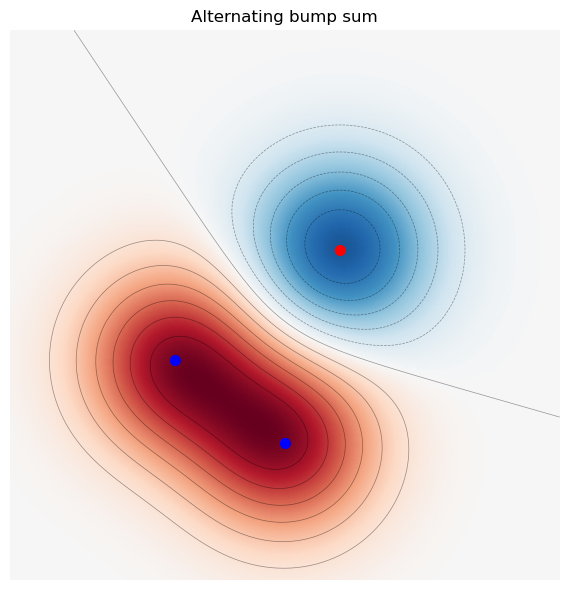

In [2]:
n = 300
t = np.linspace(0, 1, n)
Y, X = np.meshgrid(t, t)
sigma = 0.12

def gaussian_bump(center, sigma=sigma):
    """2D Gaussian bump centered at complex number center."""
    zr, zi = center.real, center.imag
    return np.exp(-((X - zr)**2 + (Y - zi)**2) / (2 * sigma**2))

def bump_field(centers, signs, sigma=sigma):
    """Alternating sum of Gaussian bumps: sum_i sign_i * G_{z_i}."""
    M = np.zeros((n, n))
    for z, s in zip(centers, signs):
        M += s * gaussian_bump(z, sigma)
    return M

def plot_bump_field(M, title, ax=None, centers=None, signs=None):
    if ax is None: fig, ax = plt.subplots(figsize=(5,5))
    r = 15
    vmax = np.abs(M).max()
    ax.imshow(M.T, extent=[0,1,0,1], origin='lower', cmap='RdBu_r',
              vmin=-vmax, vmax=vmax)
    ax.contour(X, Y, M, levels=np.linspace(-vmax, vmax, r), colors='k',
               linewidths=0.5, alpha=0.4)
    if centers is not None:
        for z, s in zip(centers, signs):
            c_col = 'blue' if s > 0 else 'red'
            ax.plot(z.real, z.imag, '.', color=c_col, ms=14)
    ax.set_title(title); ax.axis('off')

# Simple example: 3 bumps with alternating signs
rng = np.random.default_rng(42)
centers_a = [0.3+0.4j, 0.6+0.6j, 0.5+0.25j]
signs_a = [1, -1, 1]
Ma = bump_field(centers_a, signs_a)

fig, ax = plt.subplots(figsize=(6, 6))
plot_bump_field(Ma, 'Alternating bump sum', ax=ax, centers=centers_a, signs=signs_a)
plt.tight_layout(); plt.savefig('bumps_simple.png', dpi=100, bbox_inches='tight'); plt.show()

### Product of two bump fields

We compute the **product** $P = M_1 \cdot M_2$ of two bump fields. The peaks of $P$ appear at the **midpoints** of pairs of same-sign bumps from $M_1$ and $M_2$, while cancellations occur at midpoints of opposite-sign pairs.

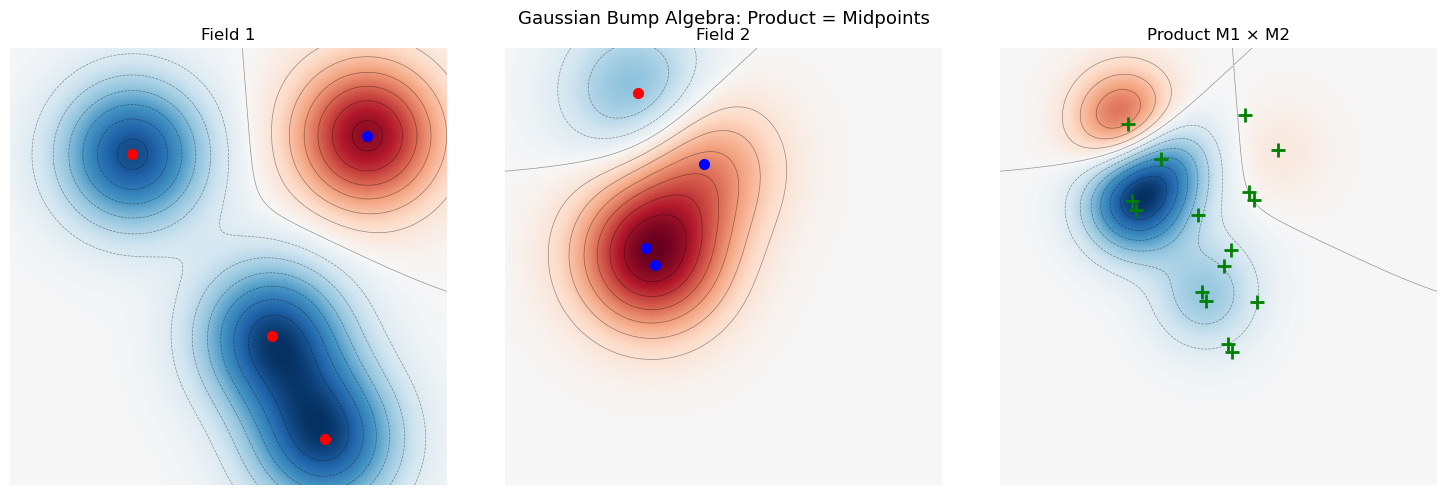

In [3]:
rng2 = np.random.default_rng(7)

# Two sets of bumps
n_bumps = 4
centers1 = rng2.uniform(0.1, 0.9, n_bumps) + 1j * rng2.uniform(0.1, 0.9, n_bumps)
signs1 = rng2.choice([-1, 1], n_bumps)

centers2 = rng2.uniform(0.1, 0.9, n_bumps) + 1j * rng2.uniform(0.1, 0.9, n_bumps)
signs2 = rng2.choice([-1, 1], n_bumps)

M1 = bump_field(centers1, signs1)
M2 = bump_field(centers2, signs2)
P = M1 * M2

# Theoretical midpoints
midpoints = [(c1 + c2) / 2 for c1 in centers1 for c2 in centers2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_bump_field(M1, 'Field 1', ax=axes[0], centers=centers1, signs=signs1)
plot_bump_field(M2, 'Field 2', ax=axes[1], centers=centers2, signs=signs2)
plot_bump_field(P, 'Product M1 × M2', ax=axes[2])
for mp in midpoints:
    axes[2].plot(mp.real, mp.imag, 'g+', ms=10, mew=2)
plt.suptitle('Gaussian Bump Algebra: Product = Midpoints', fontsize=13)
plt.tight_layout(); plt.savefig('bumps_product.png', dpi=100, bbox_inches='tight'); plt.show()

### Parametric bump patterns

We explore structured patterns: bumps placed on geometric configurations (circle, grid, random), and their products, revealing the midpoint geometry.

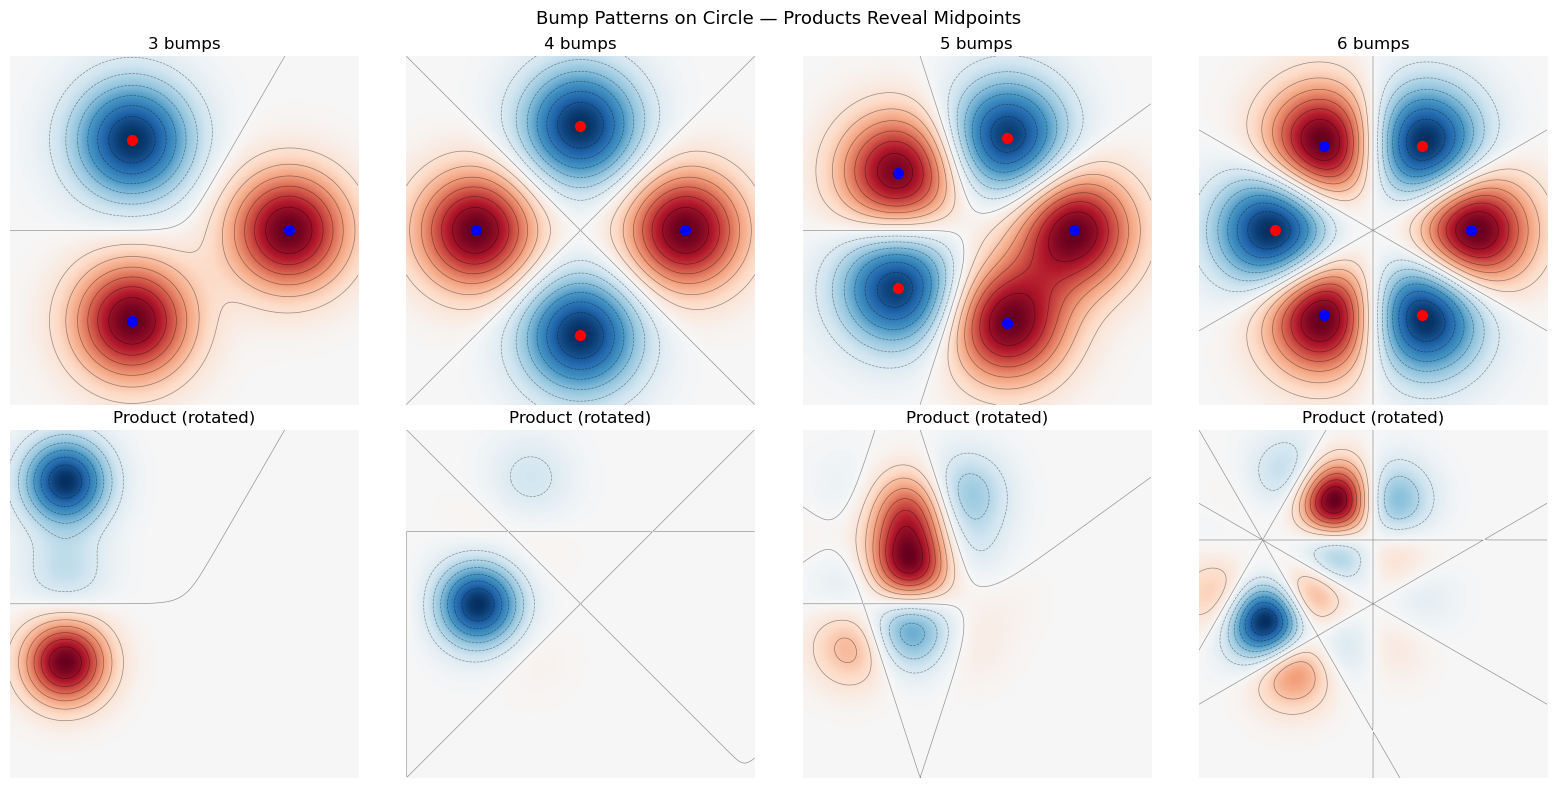

In [4]:
# Pattern: bumps on a circle
def circle_bumps(k, r=0.3, cx=0.5, cy=0.5, alternating=True):
    angles = 2 * np.pi * np.arange(k) / k
    centers = cx + r * np.cos(angles) + 1j * (cy + r * np.sin(angles))
    signs = [(-1)**i if alternating else 1 for i in range(k)]
    return centers, signs

configs = [
    circle_bumps(3, r=0.3, alternating=True),
    circle_bumps(4, r=0.3, alternating=True),
    circle_bumps(5, r=0.28, alternating=True),
    circle_bumps(6, r=0.28, alternating=True),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, (centers_c, signs_c) in enumerate(configs):
    M = bump_field(centers_c, signs_c)
    k_c = len(centers_c)
    plot_bump_field(M, f'{k_c} bumps', ax=axes[0, col],
                    centers=centers_c, signs=signs_c)
    # Product of field with itself rotated
    centers_rot = centers_c * np.exp(1j * np.pi / k_c)
    M_rot = bump_field(centers_rot, signs_c)
    P = M * M_rot
    plot_bump_field(P, f'Product (rotated)', ax=axes[1, col])

plt.suptitle('Bump Patterns on Circle — Products Reveal Midpoints', fontsize=13)
plt.tight_layout(); plt.savefig('bumps_circle.png', dpi=100, bbox_inches='tight'); plt.show()

### Interactive: build a bump field

In [ ]:
def show_bumps(k=4, sigma_val=0.12, show_product=True, seed=42):
    rng_w = np.random.default_rng(seed)
    cc = rng_w.uniform(0.1, 0.9, k) + 1j * rng_w.uniform(0.1, 0.9, k)
    ss = rng_w.choice([-1, 1], k)
    cc2 = rng_w.uniform(0.1, 0.9, k) + 1j * rng_w.uniform(0.1, 0.9, k)
    ss2 = rng_w.choice([-1, 1], k)

    M_w1 = bump_field(cc, ss, sigma=sigma_val)
    M_w2 = bump_field(cc2, ss2, sigma=sigma_val)

    fig, axes = plt.subplots(1, 3 if show_product else 2, figsize=(14, 5))
    plot_bump_field(M_w1, 'Field 1', ax=axes[0], centers=cc, signs=ss)
    plot_bump_field(M_w2, 'Field 2', ax=axes[1], centers=cc2, signs=ss2)
    if show_product:
        plot_bump_field(M_w1 * M_w2, 'Product', ax=axes[2])
    plt.tight_layout(); plt.show()

interact(show_bumps,
         k=IntSlider(min=2, max=8, step=1, value=4, description='#bumps'),
         sigma_val=FloatSlider(min=0.04, max=0.25, step=0.01, value=0.12, description='σ'),
         seed=IntSlider(min=0, max=20, step=1, value=42));

### Snippet

In [5]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt

    fig, axes = _plt.subplots(2, 4, figsize=(14, 7))
    for col, (centers_c, signs_c) in enumerate(configs):
        M_s = bump_field(centers_c, signs_c)
        k_c = len(centers_c)
        vmax_s = np.abs(M_s).max()
        axes[0, col].imshow(M_s.T, extent=[0,1,0,1], origin='lower',
                            cmap='RdBu_r', vmin=-vmax_s, vmax=vmax_s)
        axes[0, col].set_title(f'{k_c} bumps', fontsize=10); axes[0, col].axis('off')
        centers_rot = centers_c * np.exp(1j * np.pi / k_c)
        M_rot2 = bump_field(centers_rot, signs_c)
        P_s = M_s * M_rot2
        vmax_p = np.abs(P_s).max()
        axes[1, col].imshow(P_s.T, extent=[0,1,0,1], origin='lower',
                            cmap='RdBu_r', vmin=-vmax_p, vmax=vmax_p)
        axes[1, col].set_title('Product', fontsize=10); axes[1, col].axis('off')
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- The product of two Gaussians is a Gaussian centered at their **midpoint**, with amplitude depending on their separation.
- Alternating sums of Gaussians produce structured fields with level sets reflecting the arrangement geometry.
- Products of two bump fields reveal the **midpoint cloud** of all pairs of centers — a form of combinatorial correlation.
- This algebra connects to **mixture models**, **kernel methods**, and **wavelet analysis**.

## Bibliography

- B. Schölkopf & A. Smola, *Learning with Kernels*, MIT Press, 2002.
- S. Mallat, *A Wavelet Tour of Signal Processing*, Academic Press, 1999.